### Testing diffrent optimizers
#### In this notebook i will test my implementation of 4 diffrent optimizers:
#### SGD, Momentum, RMSProp and Adam

We will train 4 neural networks on MNIST dataset (hand-written digit) each one with a diffrent optimizer
but similliar configurations and test
them based on:
- Training time
- Testing accuracy
- Testing loss

In [9]:
#Change directory for importing 

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

In [10]:
#Load and preprocess MNIST dataset from keras
from load_mnist import load_handwritten_digits

X_train, y_train, X_test, y_test = load_handwritten_digits()

In [11]:
import time #For calculating training time

optimizers = ["SGD", "Momentum", "RMSProp", "Adam"]

accuracies = list()
losses = list()
times = list()

from build_model import build_mnist_model

In [12]:
btchsize = 32 #Best approved batch size

In [13]:
for indx, optim in enumerate(optimizers):
    print(f"------------- Optimizer: {optim} ----------------")
    net = build_mnist_model(optimizer= optim)

    start = time.perf_counter() #Timer starts!

    net.fit(X = X_train,
           y = y_train,
           epoch = 5,
           batch_size = btchsize,
           monitor_every_n = 5)

    elapsed = time.perf_counter() - start #Timer stops!
    times.append(elapsed)

    accuracy, loss = net.evaluate(X_test, y_test)
    
    accuracies.append(accuracy)
    losses.append(loss)

    print(f"Optimizer: {optim}, time: {elapsed}")
    print(f"Optimizer: {optim}, accuracy: {accuracy}")
    print(f"Optimizer: {optim}, loss: {loss}")

------------- Optimizer: SGD ----------------
epoch: 5, loss: 0.4304180461431987
Optimizer: SGD, time: 36.12175950000528
Optimizer: SGD, accuracy: 0.9026
Optimizer: SGD, loss: 0.42158217823891475
------------- Optimizer: Momentum ----------------
epoch: 5, loss: 0.43154291375546655
Optimizer: Momentum, time: 39.44029539998155
Optimizer: Momentum, accuracy: 0.9024
Optimizer: Momentum, loss: 0.42267101766365167
------------- Optimizer: RMSProp ----------------
epoch: 5, loss: 0.04446966554124491
Optimizer: RMSProp, time: 47.63130249991082
Optimizer: RMSProp, accuracy: 0.9763
Optimizer: RMSProp, loss: 0.0776365035226383
------------- Optimizer: Adam ----------------
epoch: 5, loss: 0.045037692842817174
Optimizer: Adam, time: 61.63823340006638
Optimizer: Adam, accuracy: 0.9761
Optimizer: Adam, loss: 0.07979537856511355


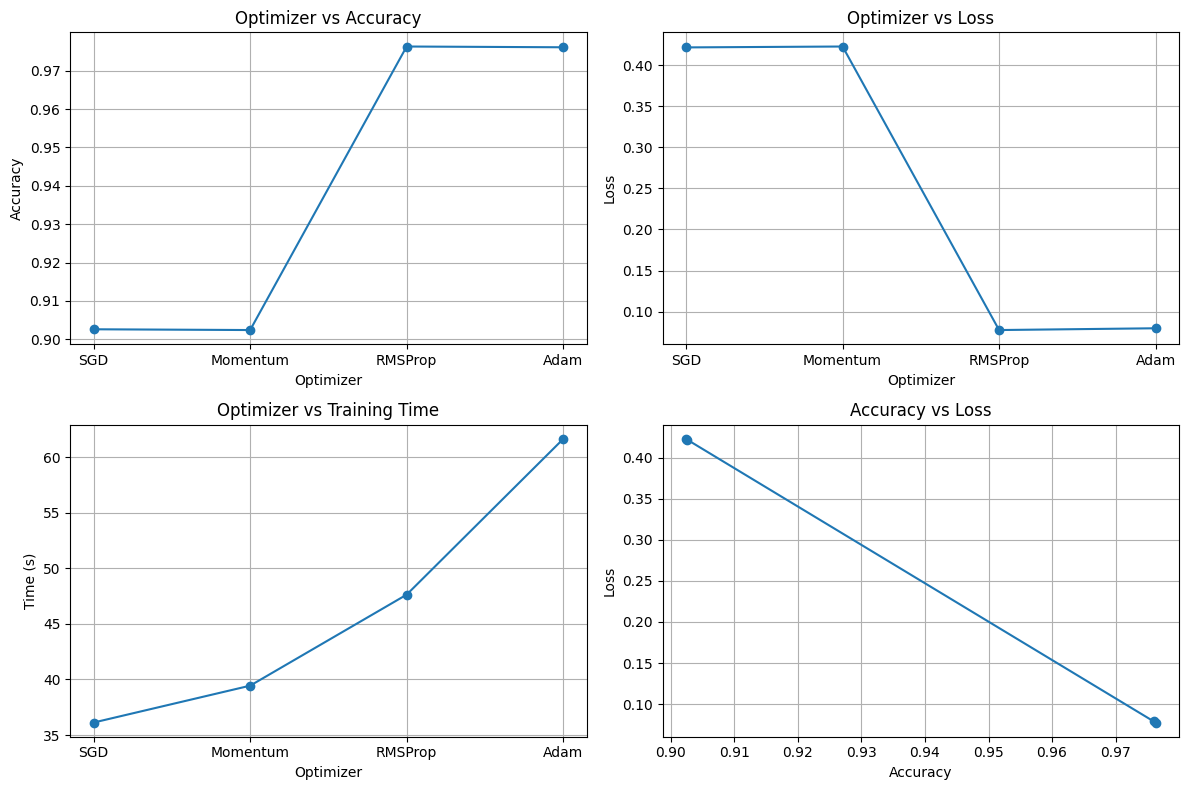

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

#Optimizer vs Accuracy
axes[0, 0].plot(optimizers, accuracies, marker="o")
axes[0, 0].set_xlabel("Optimizer")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].set_title("Optimizer vs Accuracy")
axes[0, 0].grid()

#Optimizer vs Loss
axes[0, 1].plot(optimizers, losses, marker="o")
axes[0, 1].set_xlabel("Optimizer")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].set_title("Optimizer vs Loss")
axes[0, 1].grid()

#Optimizer vs Time
axes[1, 0].plot(optimizers, times, marker="o")
axes[1, 0].set_xlabel("Optimizer")
axes[1, 0].set_ylabel("Time (s)")
axes[1, 0].set_title("Optimizer vs Training Time")
axes[1, 0].grid()

# Accuracy vs Loss
axes[1, 1].plot(accuracies, losses, marker="o")
axes[1, 1].set_xlabel("Accuracy")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].set_title("Accuracy vs Loss")
axes[1, 1].grid()

plt.tight_layout()

plt.savefig("test_results\\optimizer_test.png")
plt.show()

### Conclusion

SGD and Momentum share very similiar results (suspiciously similar) and they also have a large margin in all aspects from RMSProp
and Adam optimizer

RMSProp and Adam offer way better accuracies and lower losses but they also take more time to train

Seeing the "Optimizer vs Training Time" plot, we can say that RMSProp achieved better results with
less training time (in this case) therefore it is a better choice.